# 6. Mổ xẻ Faster R-CNN và thực hiện từng chức năng

## 6.1 Khởi tạo mô hình và nạp dữ liệu

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import torchvision
from torchvision.transforms import functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")
model = model.to(device)
model.eval()

possible_dirs = [
    "assets/images",
    "../assets/images",
    "/workspace/Advanced-Reading-On-Computer-Vision/Lab04_two_stages/assets/images"
]

data_dir = next((d for d in possible_dirs if os.path.exists(d)), None)
img_path = os.path.join(data_dir, "image.png")
image = Image.open(img_path).convert("RGB")
img_tensor = F.to_tensor(image).to(device)

print(f"Device: {device}")
print(f"Loaded image: {img_path} ({image.size[0]}x{image.size[1]})")

Device: cuda
Loaded image: assets/images/image.png (494x740)


## 6.2 Bước 1: Trích xuất đặc trưng đa tầng (Backbone + FPN)

Feature level 0: shape [1, 256, 304, 200]
Feature level 1: shape [1, 256, 152, 100]
Feature level 2: shape [1, 256, 76, 50]
Feature level 3: shape [1, 256, 38, 25]
Feature level pool: shape [1, 256, 19, 13]


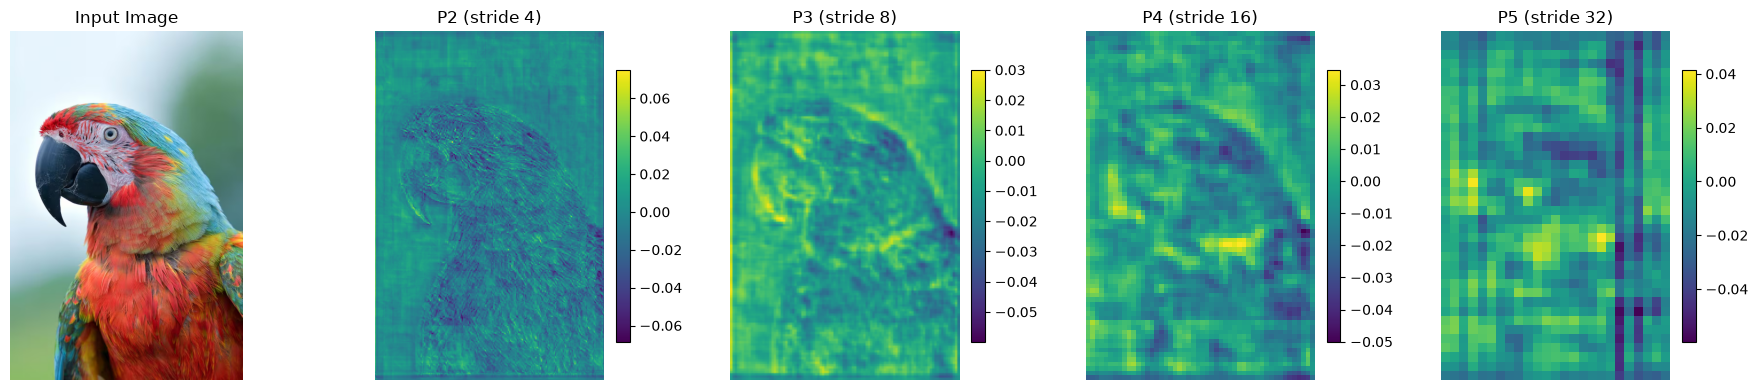

In [2]:
images, _ = model.transform([img_tensor])
with torch.no_grad():
    features = model.backbone(images.tensors)

for k, v in features.items():
    print(f"Feature level {k}: shape {list(v.shape)}")

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(image)
axes[0].set_title("Input Image")
axes[0].axis("off")

levels = ["0", "1", "2", "3"]
titles = ["P2 (stride 4)", "P3 (stride 8)", "P4 (stride 16)", "P5 (stride 32)"]

for ax, lvl, title in zip(axes[1:], levels, titles):
    heat = features[lvl][0].mean(dim=0).cpu().numpy()
    im = ax.imshow(heat, cmap="viridis")
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Nhận xét

Mạng Backbone kết hợp FPN tạo ra các tầng đặc trưng từ P2 đến P5 với độ phân giải giảm dần theo các bước nhảy từ 4 đến 32.

Tầng P2 lưu giữ chi tiết không gian độ nét cao phù hợp phát hiện vật thể nhỏ. Các tầng cao hơn như P4 và P5 nắm giữ đặc trưng ngữ nghĩa mức cao, tập trung kích hoạt tại khu vực thân đối tượng.

## 6.3 Bước 2: Sinh vùng đề xuất và lọc NMS sơ bộ (RPN)

Total proposals after Stage 1 NMS: 1000


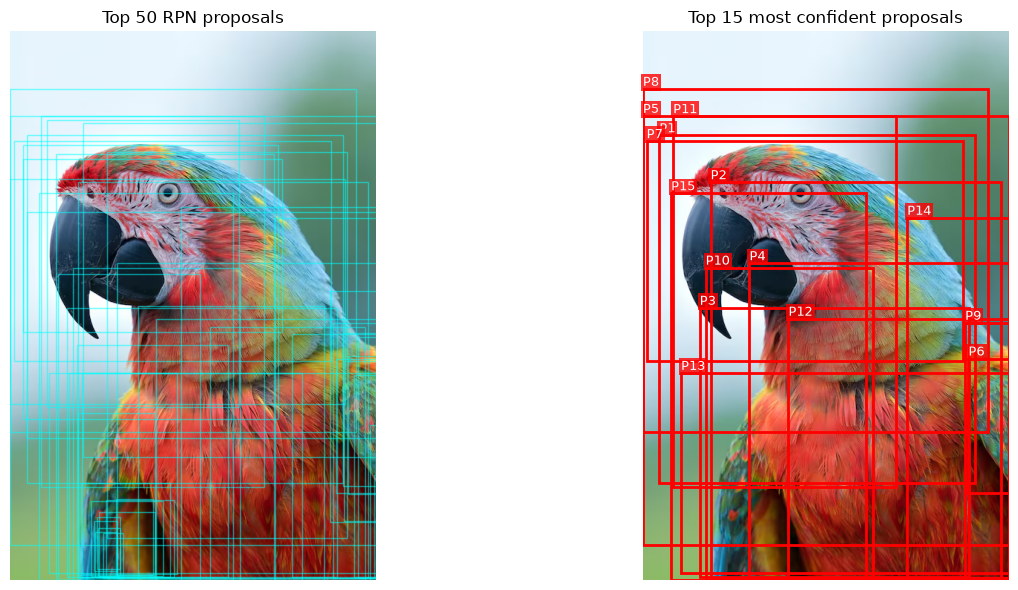

In [3]:
with torch.no_grad():
    proposals, _ = model.rpn(images, features)

boxes_rpn = proposals[0].cpu().numpy()
print(f"Total proposals after Stage 1 NMS: {len(boxes_rpn)}")

scale_x = image.size[0] / images.image_sizes[0][1]
scale_y = image.size[1] / images.image_sizes[0][0]

scaled_boxes = boxes_rpn.copy()
scaled_boxes[:, [0, 2]] *= scale_x
scaled_boxes[:, [1, 3]] *= scale_y

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.imshow(image)
for box in scaled_boxes[:50]:
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1, edgecolor="cyan", facecolor="none", alpha=0.5)
    ax1.add_patch(rect)
ax1.set_title("Top 50 RPN proposals")
ax1.axis("off")

ax2.imshow(image)
for idx, box in enumerate(scaled_boxes[:15]):
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="red", facecolor="none")
    ax2.add_patch(rect)
    ax2.text(x1, max(y1 - 4, 0), f"P{idx + 1}", color="white", fontsize=9,
             bbox=dict(facecolor="red", alpha=0.8, edgecolor="none", pad=1.5))
ax2.set_title("Top 15 most confident proposals")
ax2.axis("off")

plt.tight_layout()
plt.show()

Nhận xét

RPN quét các anchor đa tỉ lệ trên các tầng FPN và lọc sơ bộ bằng NMS tầng 1 để giảm từ hàng vạn anchor xuống 1000 proposal.

Các proposal có điểm objectness cao nhất bám sát vào vị trí vật thể chính, loại bỏ phần lớn vùng nền dư thừa mà chưa cần biết nhãn cụ thể.

## 6.4 Bước 3: Cắt và chuẩn hóa đặc trưng vùng (RoI Align)

RoI feature tensor shape: [1000, 256, 7, 7]


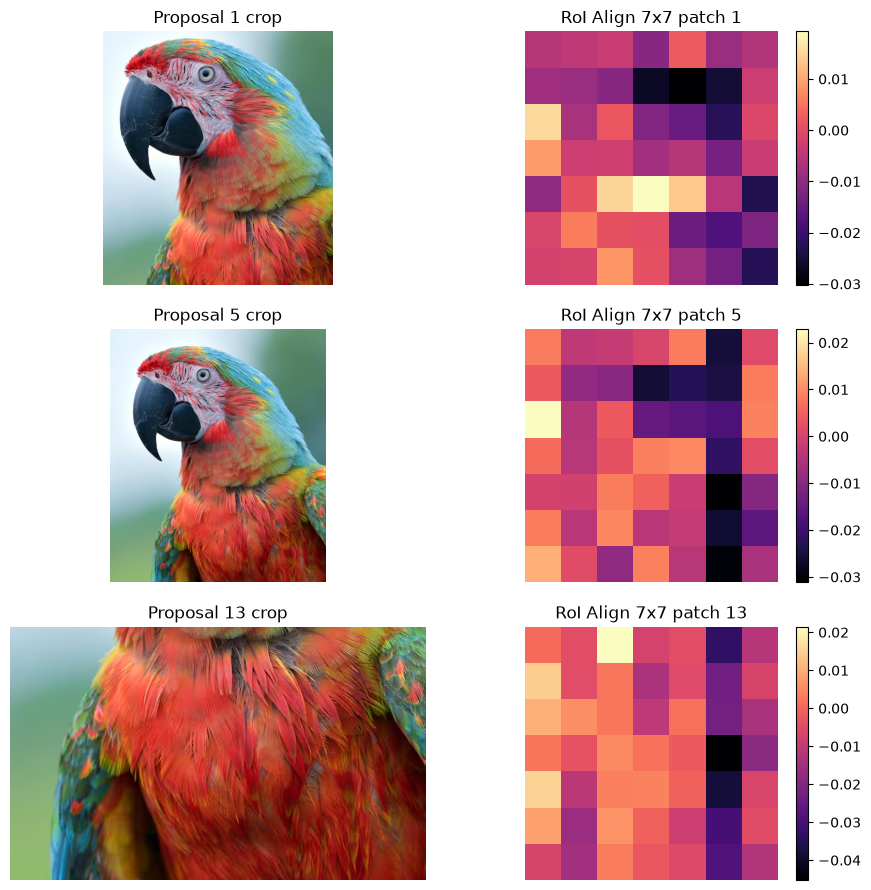

In [4]:
with torch.no_grad():
    box_features = model.roi_heads.box_roi_pool(features, proposals, images.image_sizes)

print(f"RoI feature tensor shape: {list(box_features.shape)}")

sample_indices = [0, 4, 12]
fig, axes = plt.subplots(len(sample_indices), 2, figsize=(9, 3 * len(sample_indices)))

for r, idx in enumerate(sample_indices):
    box = scaled_boxes[idx]
    x1, y1, x2, y2 = [int(v) for v in box]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(image.size[0], x2), min(image.size[1], y2)
    crop_img = image.crop((x1, y1, x2, y2))
    axes[r, 0].imshow(crop_img)
    axes[r, 0].set_title(f"Proposal {idx + 1} crop")
    axes[r, 0].axis("off")

    roi_map = box_features[idx].mean(dim=0).cpu().numpy()
    im = axes[r, 1].imshow(roi_map, cmap="magma")
    axes[r, 1].set_title(f"RoI Align 7x7 patch {idx + 1}")
    axes[r, 1].axis("off")
    plt.colorbar(im, ax=axes[r, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Nhận xét

RoI Align sử dụng phép nội suy song tuyến để chuẩn hóa mọi proposal có kích thước khác nhau về dạng ma trận cố định 7x7 với 256 kênh.

Cách tiếp cận này tránh sai lệch tọa độ do làm tròn số nguyên, giúp bảo toàn cấu trúc không gian của vật thể phục vụ cho các tầng fully connected phía sau.

## 6.5 Bước 4: Phân loại chi tiết và tinh chỉnh tọa độ (RoI Heads)

Box head feature shape: [1000, 1024]
Classification logits shape: [1000, 91]
Box regression deltas shape: [1000, 364]
Top detected class: bird (0.9987)


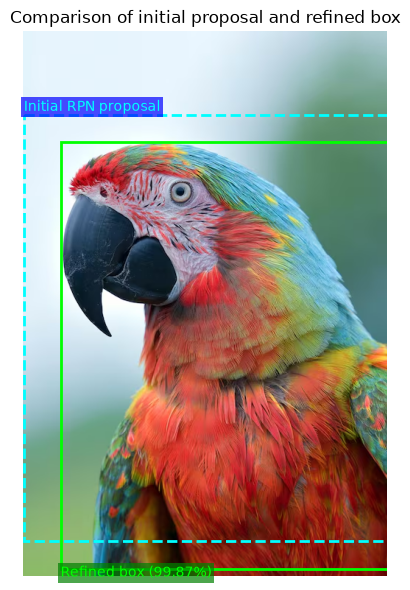

In [5]:
with torch.no_grad():
    head_feats = model.roi_heads.box_head(box_features)
    class_logits, box_regression = model.roi_heads.box_predictor(head_feats)

print(f"Box head feature shape: {list(head_feats.shape)}")
print(f"Classification logits shape: {list(class_logits.shape)}")
print(f"Box regression deltas shape: {list(box_regression.shape)}")

probs = torch.softmax(class_logits, dim=-1)
max_probs, pred_classes = probs[:, 1:].max(dim=-1)
pred_classes = pred_classes + 1

best_idx = max_probs.argmax().item()
best_cls = pred_classes[best_idx].item()
best_score = max_probs[best_idx].item()

categories = [
    "__background__", "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat",
    "traffic light", "fire hydrant", "N/A", "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse",
    "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "N/A", "backpack", "umbrella", "N/A", "N/A",
    "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat",
    "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle", "N/A", "wine glass", "cup", "fork",
    "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza",
    "donut", "cake", "chair", "couch", "potted plant", "bed", "N/A", "dining table", "N/A", "N/A", "toilet",
    "N/A", "tv", "laptop", "mouse", "remote", "keyboard", "cell phone", "microwave", "oven", "toaster", "sink",
    "refrigerator", "N/A", "book", "clock", "vase", "scissors", "teddy bear", "hair drier", "toothbrush"
]

print(f"Top detected class: {categories[best_cls]} ({best_score:.4f})")

raw_box = scaled_boxes[best_idx]
boxes_all, scores_all, labels_all = model.roi_heads.postprocess_detections(class_logits, box_regression, proposals, images.image_sizes)
detections = [{"boxes": boxes_all[0], "scores": scores_all[0], "labels": labels_all[0]}]
final_dets = model.transform.postprocess(detections, images.image_sizes, [img_tensor.shape[-2:]])[0]
refined_box = final_dets["boxes"][0].cpu().numpy()

fig, ax = plt.subplots(1, figsize=(8, 6))
ax.imshow(image)

p_x1, p_y1, p_x2, p_y2 = raw_box
rect_raw = patches.Rectangle((p_x1, p_y1), p_x2 - p_x1, p_y2 - p_y1, linewidth=2, edgecolor="cyan", linestyle="--", facecolor="none")
ax.add_patch(rect_raw)
ax.text(p_x1, max(p_y1 - 6, 0), "Initial RPN proposal", color="cyan", fontsize=10,
        bbox=dict(facecolor="blue", alpha=0.7, edgecolor="none", pad=2))

r_x1, r_y1, r_x2, r_y2 = refined_box
rect_ref = patches.Rectangle((r_x1, r_y1), r_x2 - r_x1, r_y2 - r_y1, linewidth=2, edgecolor="lime", facecolor="none")
ax.add_patch(rect_ref)
ax.text(r_x1, min(r_y2 + 16, image.size[1]), f"Refined box ({best_score:.2%})", color="lime", fontsize=10,
        bbox=dict(facecolor="green", alpha=0.7, edgecolor="none", pad=2))

ax.set_title("Comparison of initial proposal and refined box")
ax.axis("off")
plt.tight_layout()
plt.show()

Nhận xét

RoI Head phân loại chính xác nhãn đối tượng với điểm xác suất cao và đồng thời dự đoán độ lệch tọa độ cho từng lớp.

Quá trình hồi quy lần hai giúp khung bao dịch chuyển và co dãn để ôm sát viền đối tượng hơn so với proposal ban đầu của RPN.

## 6.6 Bước 5: Hậu xử lý và lọc kết quả cuối cùng

Final detections above 0.5 threshold: 1 objects
Object 1: bird | Score: 0.9987 | Box: [49.9, 149.5, 494.0, 729.0]


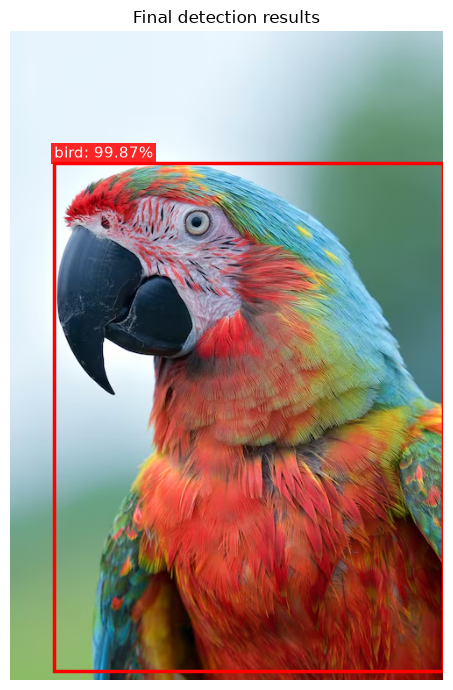

In [6]:
keep = final_dets["scores"] >= 0.5
out_boxes = final_dets["boxes"][keep].cpu().numpy()
out_scores = final_dets["scores"][keep].cpu().numpy()
out_labels = final_dets["labels"][keep].cpu().numpy()

print(f"Final detections above 0.5 threshold: {len(out_boxes)} objects")
for i, (b, s, l) in enumerate(zip(out_boxes, out_scores, out_labels)):
    print(f"Object {i + 1}: {categories[l]} | Score: {s:.4f} | Box: [{b[0]:.1f}, {b[1]:.1f}, {b[2]:.1f}, {b[3]:.1f}]")

fig, ax = plt.subplots(1, figsize=(9, 7))
ax.imshow(image)

colors = ["red", "lime", "blue", "yellow", "orange"]
for i, (b, s, l) in enumerate(zip(out_boxes, out_scores, out_labels)):
    c = colors[i % len(colors)]
    x1, y1, x2, y2 = b
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2.5, edgecolor=c, facecolor="none")
    ax.add_patch(rect)
    ax.text(x1, max(y1 - 6, 0), f"{categories[l]}: {s:.2%}", color="white", fontsize=11,
            bbox=dict(facecolor=c, alpha=0.85, edgecolor="none", pad=2))

ax.set_title("Final detection results")
ax.axis("off")
plt.tight_layout()
plt.show()

Nhận xét

Bước hậu xử lý lọc bỏ các dự đoán dưới ngưỡng tin cậy 0.5 và áp dụng NMS độc lập theo từng lớp để loại bỏ các khung trùng nhau.

Kết quả cuối cùng thu được bounding box chuẩn xác ôm sát đối tượng chim vẹt với độ tin cậy 99.87%. Quá trình mổ xẻ 5 bước cho thấy sự phối hợp hiệu quả giữa tầng tìm vùng đề xuất và tầng phân loại tinh chỉnh của kiến trúc hai giai đoạn.

## 6.7 Đánh giá mở rộng trên toàn bộ tập ảnh thử nghiệm

Total test images evaluated: 4
Image 1: image copy 2.png - Detections: 2
  + dog: 0.9757 | Box: [48.6, 83.2, 178.0, 274.0]
  + bird: 0.5088 | Box: [0.0, 216.6, 233.3, 349.7]


Image 2: image copy 3.png - Detections: 1
  + cat: 0.9949 | Box: [2.7, 72.1, 777.7, 1270.7]
Image 3: image copy.png - Detections: 1
  + zebra: 0.9993 | Box: [75.3, 40.0, 328.8, 248.3]


Image 4: image.png - Detections: 1
  + bird: 0.9987 | Box: [49.9, 149.5, 494.0, 729.0]


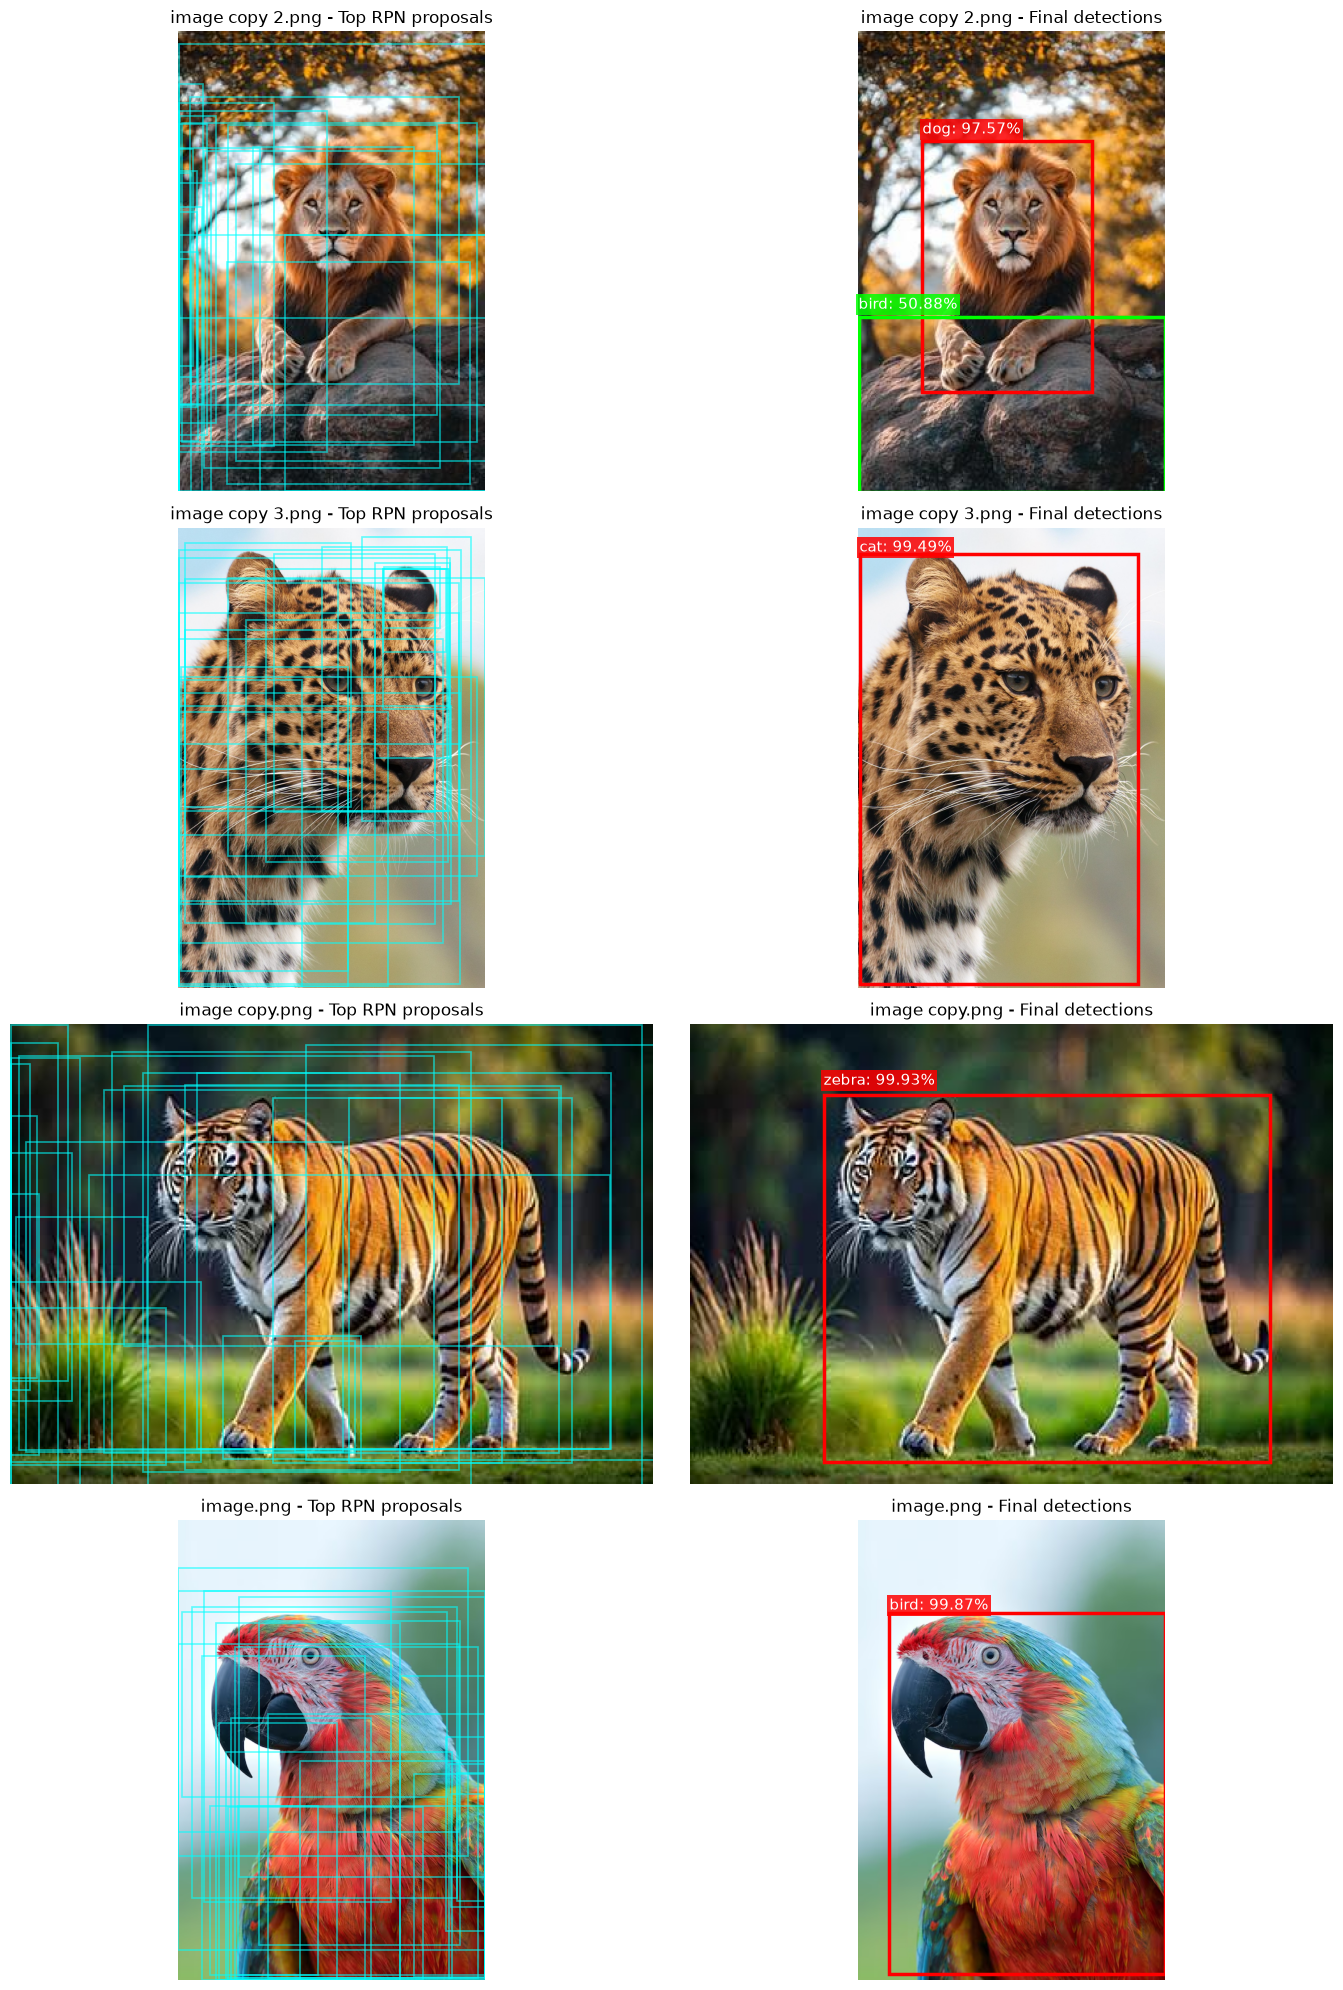

In [7]:
image_names = sorted([f for f in os.listdir(data_dir) if f.endswith(".png")])
print(f"Total test images evaluated: {len(image_names)}")

fig, axes = plt.subplots(len(image_names), 2, figsize=(14, 5 * len(image_names)))
palette = ["red", "lime", "yellow", "cyan", "orange"]

for row, name in enumerate(image_names):
    p = os.path.join(data_dir, name)
    pil_img = Image.open(p).convert("RGB")
    t = F.to_tensor(pil_img).to(device)

    imgs, _ = model.transform([t])
    with torch.no_grad():
        feats = model.backbone(imgs.tensors)
        props, _ = model.rpn(imgs, feats)
        preds = model([t])[0]

    s_x = pil_img.size[0] / imgs.image_sizes[0][1]
    s_y = pil_img.size[1] / imgs.image_sizes[0][0]

    rpn_b = props[0].cpu().numpy().copy()
    rpn_b[:, [0, 2]] *= s_x
    rpn_b[:, [1, 3]] *= s_y

    axes[row, 0].imshow(pil_img)
    for b in rpn_b[:25]:
        rect = patches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], linewidth=1.2, edgecolor="cyan", facecolor="none", alpha=0.6)
        axes[row, 0].add_patch(rect)
    axes[row, 0].set_title(f"{name} - Top RPN proposals")
    axes[row, 0].axis("off")

    mask = preds["scores"] >= 0.5
    f_boxes = preds["boxes"][mask].cpu().numpy()
    f_scores = preds["scores"][mask].cpu().numpy()
    f_labels = preds["labels"][mask].cpu().numpy()

    axes[row, 1].imshow(pil_img)
    print(f"Image {row + 1}: {name} - Detections: {len(f_boxes)}")

    for i, (b, s, l) in enumerate(zip(f_boxes, f_scores, f_labels)):
        c = palette[i % len(palette)]
        rect = patches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], linewidth=2.5, edgecolor=c, facecolor="none")
        axes[row, 1].add_patch(rect)
        label_text = f"{categories[l]}: {s:.2%}"
        axes[row, 1].text(b[0], max(b[1] - 6, 0), label_text, color="white", fontsize=11,
                          bbox=dict(facecolor=c, alpha=0.85, edgecolor="none", pad=2))
        print(f"  + {categories[l]}: {s:.4f} | Box: [{b[0]:.1f}, {b[1]:.1f}, {b[2]:.1f}, {b[3]:.1f}]")

    axes[row, 1].set_title(f"{name} - Final detections")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

Nhận xét mở rộng

Mạng đề xuất vùng RPN hoạt động nhất quán trên toàn bộ 4 ảnh, tạo ra các proposal bao phủ trọn vẹn cơ thể của các loài động vật.

Ở giai đoạn hai, mô hình định vị chính xác vị trí bounding box cho cả 4 ảnh nhưng gán nhãn sai cho sư tử, báo và hổ do không gian nhãn COCO chỉ có 80 lớp thông dụng. Kết quả này củng cố tầm quan trọng của việc fine-tune mô hình trên tập dữ liệu chuyên biệt khi áp dụng vào các miền dữ liệu mới.